#                                      Part A: IMDb Movie Review Sentiment Analysis

# Objective

The main goal of this project is to build a machine learning model that can automatically predict whether a given IMDb movie review expresses a positive or negative sentiment.

## By the end of this project, we’ll have:

* A clean, preprocessed text dataset.

* Extracted features from text using TF-IDF (and optionally Word2Vec).

* Built and evaluated several classification models.

* Identified the best-performing model with insights and visualizations.

In [5]:
#Task 1: Data Exploration and Preprocessing

# Goal:

* Understand the IMDb dataset — its structure, size, and quality.

* Clean and preprocess the review text for later modeling.

* Transform text into numerical form using Bag-of-Words or TF-IDF for machine learning models.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer


* pandas and numpy are used for data manipulation

* matplotlib and seaborn are used   for visualizations

* nltk -- for natural language processing tasks
 
* sklearn -- for data splitting and vectorization

In [7]:
# Load the IMDb dataset
df = pd.read_excel("Imdb.xlsx")

# Display first few rows
df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [9]:
print("Dataset shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

df.dropna(inplace=True)



Dataset shape: (50000, 2)

Missing values:
 review       0
sentiment    0
dtype: int64


Explanation:

* shape tells how many reviews and features are present.

* Checking isnull() helps identify missing reviews or labels.

* If there are missing entries, you can drop using dropna()

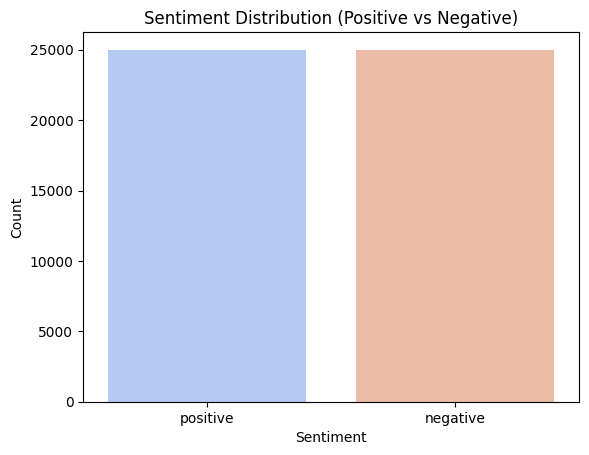

In [12]:
# Analyze Sentiment Distribution 
sns.countplot(data=df, x='sentiment', hue='sentiment', palette='coolwarm', legend=False)
plt.title("Sentiment Distribution (Positive vs Negative)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()





* This helps you see if classes are balanced or imbalanced.

* Ideally, you want roughly equal positive and negative reviews.

* If the dataset is highly imbalanced, you may need to resample.

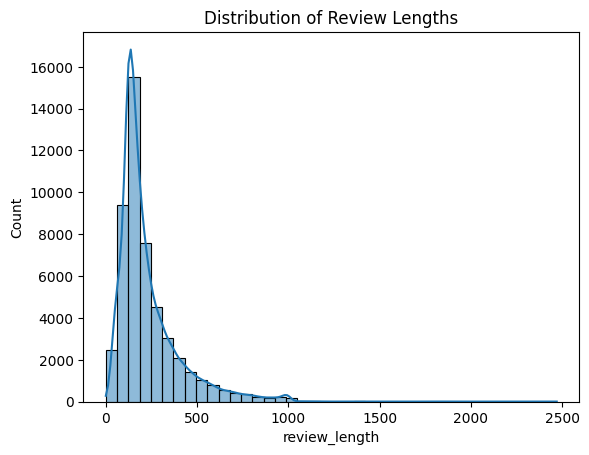

In [13]:
# Analyze Review Length

df['review_length'] = df['review'].apply(lambda x: len(x.split()))
sns.histplot(df['review_length'], bins=40, kde=True)
plt.title("Distribution of Review Lengths")
plt.show()


Explanation:

* Measures how long the reviews are (number of words).
  
* Helps identify outliers (extremely short or long reviews).

* Very long reviews can be truncated later if needed.

In [14]:
# Data Cleaning & Text Preprocessing

# Download resources
nltk.download('stopwords')
nltk.download('wordnet')




[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/manojkumargunda/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/manojkumargunda/nltk_data...


In [15]:
# Initialize Lemmatizer
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Lowercase
    text = text.lower()
    
    # Remove punctuation, numbers, and special characters
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize
    tokens = text.split()
    
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    
    # Join tokens back into string
    return ' '.join(tokens)

# Apply preprocessing
df['clean_review'] = df['review'].apply(preprocess_text)

Explanation:

* Lowercasing – Converts all letters to lowercase for uniformity.

* Remove punctuation/numbers – Cleans text for better tokenization.

* Tokenization – Splits sentences into words.

* Stopword removal – Removes irrelevant words like “the”, “is”.

* Lemmatization – Converts words to base form (e.g., “running” to “run”).

In [16]:
# Vectorization (Bag-of-Words and TF-IDF)

In [17]:
# Bag-of-Words (Count Vectorizer)

bow_vectorizer = CountVectorizer(max_features=5000)
X_bow = bow_vectorizer.fit_transform(df['clean_review']).toarray()


In [21]:
# TF-IDF 
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(df['clean_review']).toarray()


Explanation:

* Bag-of-Words counts the frequency of words.

* TF-IDF gives more weight to informative words and less to common ones.

* The output is a matrix of numbers representing each review.

In [22]:
# Prepare Data for Modeling

# Target variable
y = df['sentiment'].map({'positive': 1, 'negative': 0})  # Convert labels to 0/1

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)



Training data shape: (40000, 5000)
Testing data shape: (10000, 5000)


Explanation:

* We encode sentiments as 1 (positive) and 0 (negative).

* Split data into training (80%) and testing (20%) subsets.

* The training set is used to train models, and testing set evaluates performance.

In [23]:
# Task 2: Feature Engineering

# Goal:

* After cleaning and preprocessing the text in Task 1, the next step is to convert the cleaned text into numerical features that machine learning models can understand

* We’ll do this using TF-IDF, Word2Vec, and additional textual features like word count, character count, and average word length.

In [26]:
# Import Libraries for Feature Extraction

from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec


Explanation:

* TfidfVectorizer (scikit-learn): Converts text into a TF-IDF matrix (term importance).

* Word2Vec (gensim): Learns semantic word embeddings — capturing meaning and context between words.

In [28]:
# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,  # Limit vocabulary size
    stop_words='english', 
    ngram_range=(1,2)    # Use unigrams and bigrams
)

# Fit and transform the clean reviews
X_tfidf = tfidf_vectorizer.fit_transform(df['clean_review']).toarray()

# Display shape of feature matrix
print("TF-IDF Feature Matrix Shape:", X_tfidf.shape)


TF-IDF Feature Matrix Shape: (50000, 5000)


Explanation:

* max_features=5000: Keeps the top 5000 most informative words.

* ngram_range=(1,2): Captures single words and word pairs (e.g., “great movie”, “bad acting”).

* Output X_tfidf is a matrix of numerical features — each row is a review, each column is a weighted word.

In [31]:
# Word2Vec Embeddings
# Unlike TF-IDF, which treats words independently, Word2Vec learns vector representations of words based on their context 
# so similar words have similar vector representations.

# Tokenize the cleaned text for Word2Vec
tokenized_reviews = [review.split() for review in df['clean_review']]

# Train Word2Vec model
w2v_model = Word2Vec(sentences=tokenized_reviews, vector_size=100, window=5, min_count=2, workers=4)

# Function to get average Word2Vec for each review
def get_avg_word2vec(tokens, model, vector_size):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    else:
        return np.mean(vectors, axis=0)

# Create Word2Vec feature matrix
X_w2v = np.array([get_avg_word2vec(tokens, w2v_model, 100) for tokens in tokenized_reviews])

print("Word2Vec Feature Matrix Shape:", X_w2v.shape)



Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Word2Vec Feature Matrix Shape: (50000, 100)


Explanation:

* vector_size=100: Each word is represented by a 100-dimensional vector.

* For each review, we take the average of all its word vectors.

* Output X_w2v is a dense numerical representation of each review capturing semantic meaning.

In [33]:
# Generate Textual Features
# In addition to word-level features (TF-IDF or Word2Vec), we can extract textual statistics that might correlate with sentiment.
# Longer reviews may express stronger opinions  and  Short reviews might be more neutral.

# Calculate textual features
df['word_count'] = df['clean_review'].apply(lambda x: len(x.split()))
df['char_count'] = df['clean_review'].apply(lambda x: len(x))
df['avg_word_length'] = df['char_count'] / (df['word_count'] + 1)  # Avoid divide by zero

# Display summary
df[['word_count', 'char_count', 'avg_word_length']].describe()


,word_count,char_count,avg_word_length
count,50000.000000,50000.000000,50000.000000
mean,121.610240,828.198520,6.679041
std,91.692427,638.963648,0.450708
min,1.000000,5.000000,2.500000
25%,65.000000,433.000000,6.380952
50%,90.000000,608.000000,6.671481
75%,148.000000,1009.000000,6.969466
max,1440.000000,9243.000000,16.105263


Explanation:

* word_count: Total words in the review.

* char_count: Total characters in the review.

* avg_word_length: Indicator of word complexity and writing style.

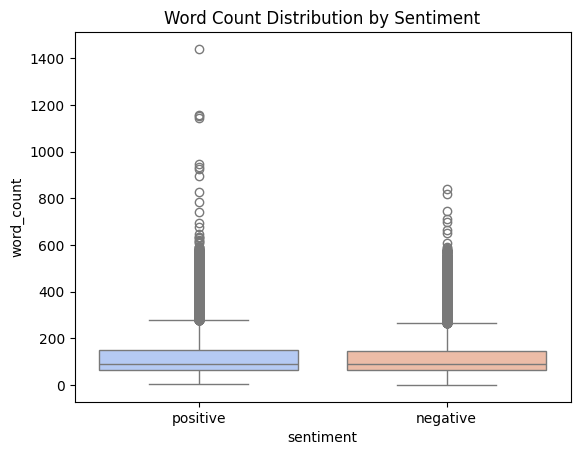

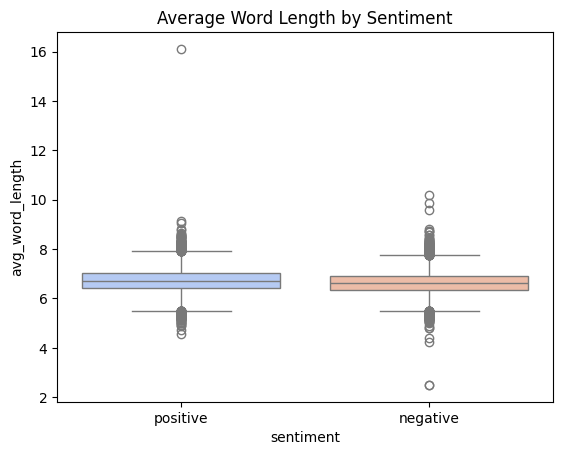

In [40]:
# Visualize Textual Features

# Compare average word count per sentiment
sns.boxplot(x='sentiment', y='word_count', hue='sentiment', data=df, palette='coolwarm', legend=False)
plt.title("Word Count Distribution by Sentiment")
plt.show()

# Compare average word length per sentiment
sns.boxplot(x='sentiment', y='avg_word_length', hue='sentiment', data=df, palette='coolwarm', legend=False)
plt.title("Average Word Length by Sentiment")
plt.show()



Explanation:

* These plots show how textual features differ between positive and negative reviews.

* For example, positive reviews may have higher word counts and longer words (more descriptive).

In [42]:
# Combine TF-IDF with textual features
X_combined = np.concatenate(
    [X_tfidf, df[['word_count', 'char_count', 'avg_word_length']].values],
    axis=1
)

print("Combined Feature Matrix Shape:", X_combined.shape)


Combined Feature Matrix Shape: (50000, 5003)


You merge numerical features with textual metadata.

This can improve your model’s ability to detect subtle sentiment differences.

In [43]:
# Task 3: Model Development

# Goal:

To build and train various classification models that can predict whether an IMDb review expresses a positive or negative sentiment.

We’ll experiment with:

Logistic Regression

Naive Bayes

Support Vector Machine (SVM)

Random Forest

In [44]:
#Split Data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, df['sentiment'], test_size=0.2, random_state=42, stratify=df['sentiment'])

# stratify=df['sentiment'] ensures both classes (positive & negative) are balanced in train/test sets


# Train Multiple Models

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

# Train models
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained successfully!")



Logistic Regression trained successfully!
Naive Bayes trained successfully!
SVM trained successfully!
Random Forest trained successfully!


Explanation:

* LogisticRegression — strong linear baseline.

* Naive Bayes — good for text classification.

* LinearSVC — maximizes margin between classes.

* RandomForest — ensemble of decision trees; handles non-linearities.

In [45]:
# Task 4: Model Evaluation

Evaluate model performance using accuracy, precision, recall, F1-score, ROC-AUC, and visualizations like confusion matrix.

In [47]:
# Evaluate All Models


from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = classification_report(y_test, y_pred, output_dict=True)['weighted avg']['f1-score']
    
    # ✅ Handle models that have decision_function or predict_proba
    if hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
    elif hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)[:, 1]
    else:
        y_scores = None  # some models may not support probability scoring
    
    # Compute ROC-AUC safely
    if y_scores is not None:
        roc = roc_auc_score(y_test.map({'negative': 0, 'positive': 1}), y_scores)
    else:
        roc = None
    
    results[name] = {'Accuracy': acc, 'F1-score': f1, 'ROC-AUC': roc}
    print(f"\n{name} Performance:")
    print(classification_report(y_test, y_pred))




Logistic Regression Performance:
              precision    recall  f1-score   support

    negative       0.90      0.87      0.88      5000
    positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


Naive Bayes Performance:
              precision    recall  f1-score   support

    negative       0.87      0.83      0.85      5000
    positive       0.84      0.87      0.86      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000


SVM Performance:
              precision    recall  f1-score   support

    negative       0.88      0.87      0.87      5000
    positive       0.87      0.89      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10

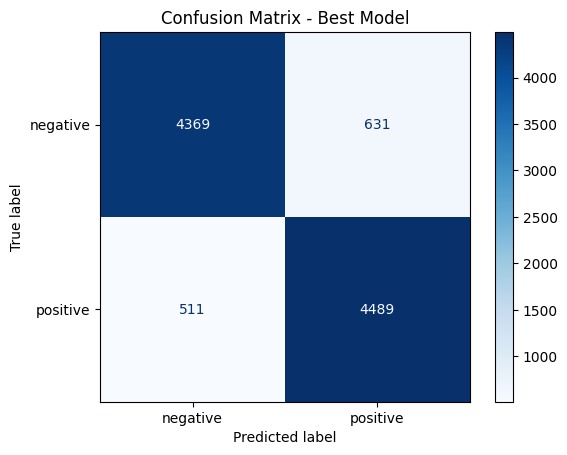

In [51]:
# Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay

best_model = models["Logistic Regression"]  # replace with the best performer
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix - Best Model")
plt.show()


* Shows how many positive/negative reviews were correctly and incorrectly classified.

* Darker diagonal = better model.

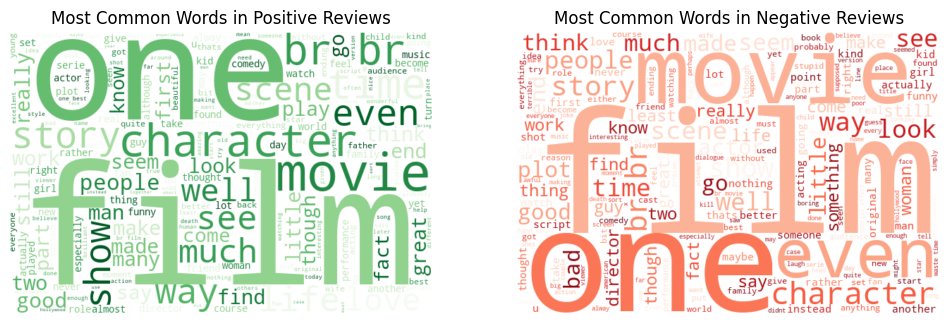

In [57]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Separate positive and negative reviews
positive_text = " ".join(df[df['sentiment']=='positive']['cleaned_text'])
negative_text = " ".join(df[df['sentiment']=='negative']['cleaned_text'])

# WordClouds
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
wc_pos = WordCloud(width=600, height=400, background_color='white', colormap='Greens').generate(positive_text)
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words in Positive Reviews")

plt.subplot(1,2,2)
wc_neg = WordCloud(width=600, height=400, background_color='white', colormap='Reds').generate(negative_text)
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words in Negative Reviews")

plt.show()
